In [17]:
%load_ext autoreload
%reload_ext autoreload

%autoreload 2
%matplotlib inline
import random
import tensorflow
from tensorflow.compat.v1.keras.backend import get_session
tensorflow.compat.v1.disable_v2_behavior()
import math
import kerasAC 
from scipy.special import softmax,expit
from kerasAC.interpret.deepshap import * 
from kerasAC.interpret.profile_shap import * 
from kerasAC.vis import * 
from kerasAC.helpers.transform_bpnet_io import * 
from kerasAC.util import * 
import pandas as pd

## for plotting 

import matplotlib 
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"]=5,5
plt.rcParams['axes.xmargin'] = 0

font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}

matplotlib.rc('font', **font)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
#load the model! 
from keras.models import load_model
from keras.utils.generic_utils import get_custom_objects
from kerasAC.metrics import * 
from kerasAC.custom_losses import * 
custom_objects={"recall":recall,
                    "sensitivity":recall,
                    "specificity":specificity,
                    "fpr":fpr,
                    "fnr":fnr,
                    "precision":precision,
                    "f1":f1,
                    "ambig_binary_crossentropy":ambig_binary_crossentropy,
                    "ambig_mean_absolute_error":ambig_mean_absolute_error,
                    "ambig_mean_squared_error":ambig_mean_squared_error,
                    "MultichannelMultinomialNLL":MultichannelMultinomialNLL}
get_custom_objects().update(custom_objects)
model=load_model("/srv/scratch/annashch/chrombpnet/gm12878_dnase/with_bias_unplugged/6dil/gm12878.dnase.with.bias.unplugged.0.hdf5")

In [3]:
import pysam 
#NOTE: FOR BACKGROUND USE HG19!!! BECAUSE BQTL FILE COORDINATES ARE GIVEN IN HG19
ref=pysam.FastaFile("/mnt/data/male.hg19.fa")
#ref=pysam.FastaFile("/mnt/data/GRCh38_no_alt_analysis_set_GCA_000001405.15.fasta")

In [4]:
import pyBigWig 


In [5]:
def get_preds(model,seq_onehot):
    preds=model.predict(seq_onehot)
    prof=np.squeeze(preds[0])
    probs=expit(prof)
    count=np.squeeze(preds[1])  
    count_track=probs*count 
    return prof,count,probs,count_track

In [6]:
import random
def get_ism_scrambled_region(model,seq,prof_pred,count_pred,mask_size=5): 
    #expand default preds to match dimensions for ISM 
    
    scrambled_seq=''.join(random.sample(seq,len(seq)))
    default_prof_expanded=np.zeros((len(seq),1000))
    default_count_expanded=np.zeros((len(seq)))
    for i in range(len(seq)): 
        default_prof_expanded[i,:]=prof_pred 
        default_count_expanded[i]=count_pred
            
    #create placeholders for ISM predictions        
    placeholder_prof=np.zeros((len(seq),1000))
    placeholder_count=np.zeros((len(seq)))

    for i in range(len(seq)): 
        mask_start=max([0,i-int(mask_size)//2])
        mask_end=min([len(seq),i+1+int(mask_size)//2])
        mask_length=mask_end-mask_start

        cur_seq=seq[0:mask_start]+scrambled_seq[mask_start:mask_end]+seq[mask_end::]
        #get predictions for the sequence with 0 mask  
        preds=model.predict([one_hot_encode([cur_seq])])
        prof=np.squeeze(preds[0])
        count=np.squeeze(preds[1])
        placeholder_prof[i,:]=prof
        placeholder_count[i]=count
    
    #subtract the WT, average across base axis 
    placeholder_prof_normed=-1*(placeholder_prof-default_prof_expanded)
    placeholder_count_normed=-1*(placeholder_count-default_count_expanded)
   
    seq_onehot=np.squeeze(one_hot_encode([seq]))
    ism_count_track=np.expand_dims(placeholder_count_normed,axis=1)*seq_onehot
    return np.squeeze(ism_count_track).flatten(), np.squeeze(placeholder_prof_normed).flatten() 

In [7]:
def get_ism_single_bp_sub(model,seq,prof_pred,count_pred): 
    #expand default preds to match dimensions for ISM 
    default_prof_expanded=np.zeros((len(seq),1000,4))
    default_count_expanded=np.zeros((len(seq),4))
    for j in range(4): 
        for i in range(len(seq)): 
            default_prof_expanded[i,:,j]=prof_pred 
            default_count_expanded[i,j]=count_pred
            
    #create placeholders for ISM predictions        
    ind_to_base={0:'A',1:'C',2:'G',3:'T'}
    placeholder_prof=np.zeros((len(seq),1000,4))
    placeholder_count=np.zeros((len(seq),4))

    for j in range(4):
        cur_allele_seqs=[]
        for i in range(len(seq)): 
            cur_allele_seqs.append(seq[0:i]+ind_to_base[j]+seq[i+1::])
        #get predictions for this allele 
        cur_allele_preds=model.predict([one_hot_encode(cur_allele_seqs)])
        cur_allele_prof=np.squeeze(cur_allele_preds[0])
        cur_allele_count=np.squeeze(cur_allele_preds[1])
        placeholder_prof[:,:,j]=cur_allele_prof
        placeholder_count[:,j]=cur_allele_count
    
    #subtract the WT, average across base axis 
    placeholder_prof_normed=placeholder_prof-default_prof_expanded
    placeholder_count_normed=placeholder_count-default_count_expanded

    placeholder_prof_normed=placeholder_prof_normed-np.expand_dims(np.mean(placeholder_prof_normed,axis=2),axis=2)
    placeholder_count_normed=placeholder_count_normed-np.expand_dims(np.mean(placeholder_count_normed,axis=1),axis=1)
    
    seq_onehot=one_hot_encode([seq])
    ism_count_track=placeholder_count_normed*seq_onehot
    
    #observed base heatmap
    ism_mat_observed=np.sum(np.expand_dims(np.squeeze(seq_onehot),axis=1)*placeholder_prof_normed,axis=2)
    
    return  np.squeeze(ism_count_track).flatten(), np.squeeze(ism_mat_observed).flatten()

In [8]:
def analyze_background(ref,
            chrom,
            summit,
            ref_allele,
            alt_allele,
            rsid,
            model,
            flank=673):
    #get the reference and alternate one-hot-encoded sequences 
    seq=ref.fetch(chrom,summit-flank,summit+flank)
    #SCRAMBLE!! 
    seq=''.join(random.sample(seq,len(seq)))
    
    ref_seq=seq[0:flank]+ref_allele+seq[flank+1::]
    assert len(ref_seq)==2*flank
    ref_onehot=one_hot_encode([ref_seq])
    
    alt_seq=seq[0:flank]+alt_allele+seq[flank+1::]
    assert len(alt_seq)==2*flank
    alt_onehot=one_hot_encode([alt_seq])
    
        
    #get predictions for reference & alternate allele 
    prof_ref,count_ref,probs_ref,count_track_ref=get_preds(model,ref_onehot)
    prof_alt,count_alt,probs_alt,count_track_alt=get_preds(model,alt_onehot)

    #get ISM scores 
    single_bp_count_flat, single_bp_ism_mat_observed_flat=get_ism_single_bp_sub(model,seq,prof_ref,count_ref)
    #get masked ISM scores (scrambled)
    scrambled_region_count_flat, scrambled_region_ism_mat_flat =get_ism_scrambled_region(model,seq,prof_ref,count_ref)
    return single_bp_ism_mat_observed_flat, single_bp_count_flat, scrambled_region_ism_mat_flat,scrambled_region_count_flat

In [9]:
#USE HG38 
#regions=pd.read_csv("bQTL.for.ism.csv",header=0,sep='\t')
regions=pd.read_csv("/srv/scratch/annashch/chrombpnet/gm12878_dnase/bQTL/pu1.formatted.csv",header=0,sep='\t')
#sample 1000 randomly
regions=regions.sample(1000,axis=0)
regions

,Chr,position,Depth,ALTdepth,REFDepth,ALTallele,POSTallele,POSTfreq,prechipfreq,pvalue,Pos0,rsid
508279,chr22,24600820,17,5,12,T,G,0.705882,0.777259,0.557909,24600819,chr22_24600819_G_T
557265,chr7,66689729,23,0,23,A,G,1.000000,0.958992,0.624573,66689728,chr7_66689728_G_A
745606,chr10,55283491,20,4,16,T,A,0.800000,0.834028,0.761724,55283490,chr10_55283490_A_T
494476,chr11,33562960,21,1,20,G,C,0.952381,0.901299,0.518970,33562959,chr11_33562959_C_G
89236,chr11,128369276,21,4,17,G,A,0.809524,0.587176,0.045261,128369275,chr11_128369275_A_G
...,...,...,...,...,...,...,...,...,...,...,...,...
246593,chr4,39978704,40,26,14,C,G,0.350000,0.462038,0.204043,39978703,chr4_39978703_G_C
672369,chr10,70095443,26,26,0,A,G,0.000000,0.022760,0.667207,70095442,chr10_70095442_G_A
433331,chr10,61569112,20,0,20,T,C,1.000000,0.945674,0.418882,61569111,chr10_61569111_C_T
103202,chr15,81608353,62,13,49,A,G,0.790323,0.671920,0.057261,81608352,chr15_81608352_G_A


In [10]:
pbw=pyBigWig.open("/oak/stanford/groups/akundaje/projects/atlas/dnase_processed/dnase/13da5ebe-0941-4855-8599-40bbcc5c58b4/call-bowtie2/shard-0/execution/ENCSR000EMT.merged.bam.bpnet.unstranded.bw",'r')

In [11]:
import pdb
single_bp_prof_background=[] 
single_bp_count_background=[] 
scrambled_prof_background=[] 
scrambled_count_background=[] 

for index,row in regions.iterrows(): 
    chrom=row['Chr']
    summit=row['Pos0']
    ref_allele=row['POSTallele']
    alt_allele=row['ALTallele']
    rsid=row['rsid']
    print(index)
    cur_single_bp_prof_background,cur_single_bp_count_background,cur_scrambled_prof_background, cur_scrambled_count_background=analyze_background(ref=ref,
            chrom=chrom,
            summit=summit,
            ref_allele=ref_allele,
            alt_allele=alt_allele,
            rsid=rsid,
            model=model,
            flank=673)
    single_bp_prof_background=single_bp_prof_background+cur_single_bp_prof_background.tolist()
    single_bp_count_background=single_bp_count_background+cur_single_bp_count_background.tolist()
    scrambled_prof_background=scrambled_prof_background+cur_scrambled_prof_background.tolist()
    scrambled_count_background=scrambled_count_background+cur_scrambled_count_background.tolist()
        

508279
Instructions for updating:
This property should not be used in TensorFlow 2.0, as updates are applied automatically.
557265
745606
494476
89236
47845
85504
885263
846939
144999
506811
576363
542203
535825
270359
865747
661132
169080
30266
99522
250010
336240
398992
810382
528056
323602
16336
904404
912744
774302
970945
775927
961567
216746
883109
32417
49419
772862
670014
334191
926968
958884
115651
597776
161113
453271
697928
560173
876229
764385
753620
669206
857743
524561
78395
278640
505851
620654
648862
643022
622165
927856
431478
538707
623948
738827
754916
435245
312076
843411
428276
989593
976849
393901
5907
990470
848667
406389
617339
552724
676797
321990
710804
786868
554014
595519
510118
810733
933314
170679
393419
308587
811267
79005
784390
955845
644960
598524
195093
731028
553538
270254
63115
739190
548730
86078
687067
720707
927226
473818
166419
742669
333203
666411
31918
56265
996993
442946
198701
596398
368153
123283
262909
883249
829757
219518
397654
479623
753

KeyboardInterrupt: 

Text(0.5, 1.0, 'Single BP sub, Profile')

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


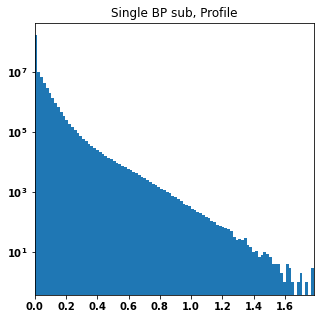

In [18]:
plt.hist(abs(np.array(single_bp_prof_background)),bins=100)
plt.yscale('log')
plt.title("Single BP sub, Profile")

Text(0.5, 1.0, 'Single BP sub, Count')

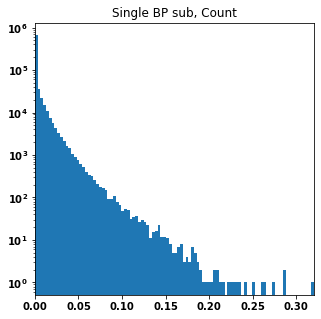

In [19]:
plt.hist(abs(np.asarray(single_bp_count_background)),bins=100)
plt.yscale('log')

plt.title("Single BP sub, Count")

Text(0.5, 1.0, 'Scrambled 5bp window, Profile')

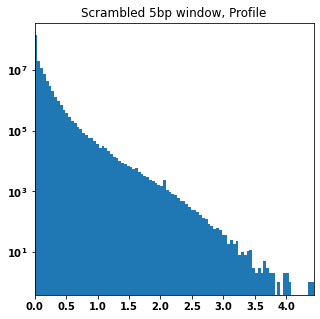

In [20]:
plt.hist(abs(np.asarray(scrambled_prof_background)),bins=100)
plt.yscale('log')

plt.title("Scrambled 5bp window, Profile")

Text(0.5, 1.0, 'Scrambled 5bp window, Count')

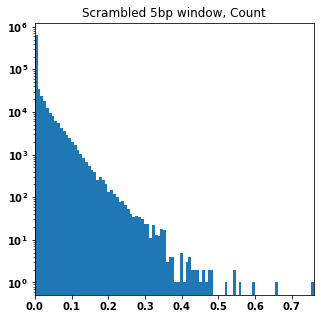

In [21]:
plt.hist(abs(np.asarray(scrambled_count_background)),bins=100)
plt.yscale('log')

plt.title("Scrambled 5bp window, Count")

In [16]:
backgrounds={}
backgrounds['single_bp_prof']=single_bp_prof_background
backgrounds['single_bp_count']=single_bp_count_background
backgrounds['scrambled_prof']=scrambled_prof_background
backgrounds['scrambled_count']=scrambled_count_background
import pickle
import pickle
with open('backgrounds.pickle', 'wb') as handle:
    pickle.dump(backgrounds, handle, protocol=pickle.HIGHEST_PROTOCOL)

